Se han encontrado 7 archivos Parquet.
Concatenando archivos... Por favor, espera.
¡Hecho! Dataset total con 1,916,757 registros cargados en RAM.

--- DISTRIBUCIÓN GLOBAL DE SERVICIOS ---
                         Cantidad  Porcentaje (%)
service                                          
dns                        879490           45.88
ssl                        860606           44.90
desconocido                154477            8.06
http                         9847            0.51
ntp                          6628            0.35
gssapi                       1161            0.06
ntlm,smb,gssapi               807            0.04
dhcp                          720            0.04
gssapi,smb,ntlm               700            0.04
gssapi,smb,ntlm,dce_rpc       372            0.02
smb,dce_rpc,ntlm,gssapi       361            0.02
ntlm,dce_rpc,gssapi,smb       351            0.02
ntlm,gssapi,smb               334            0.02
smb,gssapi,ntlm               290            0.02
gssapi,dce_rp

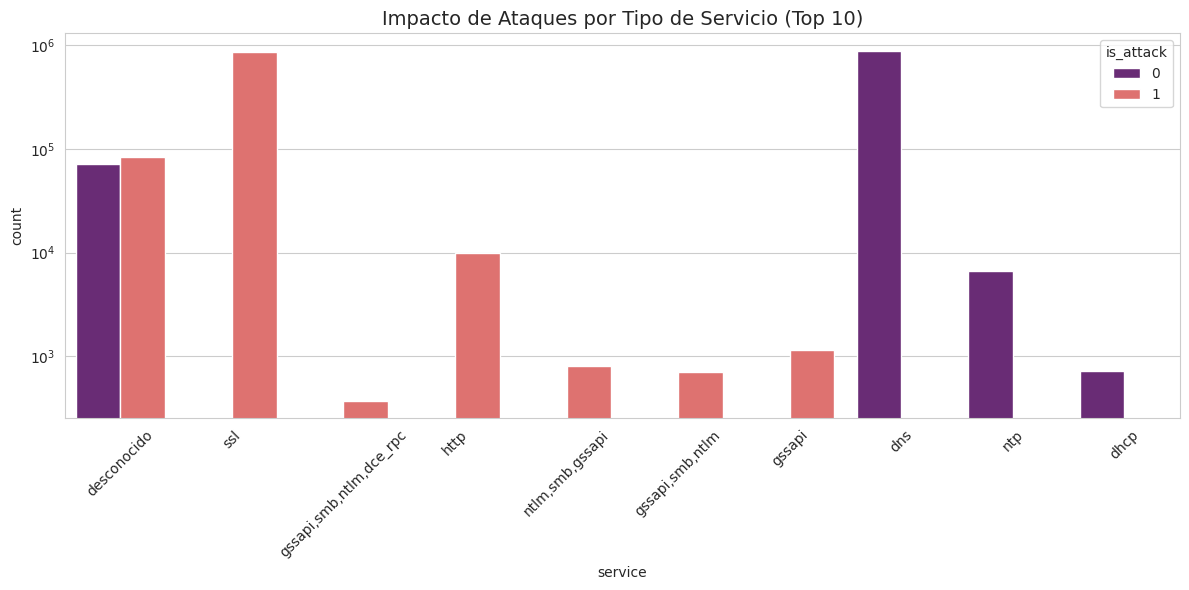

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. LOCALIZACIÓN DE LOS ARCHIVOS
# Supongamos que tus parquets están en una subcarpeta llamada 'datos'
# El asterisco '*' buscará todos los archivos que terminen en .parquet

archivos_parquet = glob.glob("*.parquet")

print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

# 2. CARGA Y CONCATENACIÓN EFICIENTE
print("Concatenando archivos... Por favor, espera.")
lista_df = []

for f in archivos_parquet:
    # Cargamos solo las columnas necesarias para el diagnóstico y ahorrar RAM
    # Si luego necesitas todas, quita el parámetro 'columns'
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

# Unimos todo en un solo DataFrame gigante
df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados en RAM.")

# 3. DIAGNÓSTICO DE LA COLUMNA SERVICE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')

resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})

print("\n--- DISTRIBUCIÓN GLOBAL DE SERVICIOS ---")
print(resumen)

# 4. ANÁLISIS DE ATAQUES POR SERVICIO
# Definimos si es ataque basándonos en la etiqueta MITRE
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(int)

# Tabla comparativa
ct = pd.crosstab(df['service'], df['is_attack'])
ct.columns = ['Benigno', 'Ataque']
ct['% de Riesgo'] = (ct['Ataque'] / (ct['Benigno'] + ct['Ataque']) * 100).round(2)

print("\n--- RANKING DE SERVICIOS POR NIVEL DE AMENAZA ---")
print(ct.sort_values(by='Ataque', ascending=False).head(15))

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log') # Escala logarítmica para ver ataques minoritarios
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()